# Stock Market Forecasting using Time Series Analysis

## Overview

This project develops a time series forecasting pipeline for stock market data from the Saudi Exchange (Tadawul). The workflow covers data extraction, preprocessing, exploratory data analysis (EDA), feature engineering, and predictive modeling to forecast future market behavior.

### Objectives
- Load and organize multiple stock market datasets.
- Clean and preprocess historical trading data.
- Perform exploratory data analysis to identify trends and patterns.
- Engineer meaningful features for forecasting.
- Train and evaluate time series forecasting models.
- Visualize historical data and prediction results.

### Tools & Technologies
- Python
- Pandas & NumPy
- Matplotlib & Seaborn
- Scikit-learn
- Time Series Forecasting Techniques

### Project Workflow
1. Data Extraction
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Model Development
6. Model Evaluation
7. Visualization of Results

This project demonstrates an end-to-end data science workflow for financial time series forecasting using Python.

In [2]:
# ============================================================
# Stock Market Forecasting Project
# Saudi Exchange (Tadawul)
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import zipfile
import glob

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path

In [3]:
# Project folders

PROJECT = Path.cwd()

DATA_FOLDER = PROJECT / "dataset"

OUTPUT_FOLDER = PROJECT / "outputs"

PLOT_FOLDER = OUTPUT_FOLDER / "plots"

MODEL_FOLDER = OUTPUT_FOLDER / "models"

RESULT_FOLDER = OUTPUT_FOLDER / "results"

for folder in [
    DATA_FOLDER,
    OUTPUT_FOLDER,
    PLOT_FOLDER,
    MODEL_FOLDER,
    RESULT_FOLDER
]:
    folder.mkdir(exist_ok=True)

print("Folders Created Successfully")

Folders Created Successfully


In [4]:
ZIP_FILE = "Statistical_Bulletin2Equities.zip"

with zipfile.ZipFile(ZIP_FILE,"r") as zip_ref:

    zip_ref.extractall(DATA_FOLDER)

print("ZIP Extracted Successfully")

ZIP Extracted Successfully


In [5]:
csv_files = glob.glob(str(DATA_FOLDER/"*.csv"))

print("Number of CSV Files :",len(csv_files))

for file in csv_files:

    print(os.path.basename(file))

Number of CSV Files : 20
 إجمالي الإيرادات - نمو.csv
 عدد محافظ الأفراد - تاسي.csv
 قيم ونسب الملكية - تاسي.csv
إجمالي الأصول - تاسي.csv
إجمالي الأصول - نمو.csv
إجمالي الإيرادات - تاسي.csv
إجمالي الدين - نمو.csv
إجمالي حقوق المساهمين - نمو.csv
اجمالي الدين - تاسي.csv
الأسهم.csv
التداولات خارج المنصة.csv
المؤشرات المالية لسوق الأسهم.csv
حقوق المساهمين - تاسي.csv
صافي الدخل - تاسي.csv
صافي الدخل - نمو.csv
قيم ونسب التداولات - تاسي.csv
قيم ونسب التداولات حسب السلوك.csv
قيم ونسب الملكية حسب السلوك.csv
مؤشرات سوق الأسهم - نمو.csv
مؤشرات سوق الأسهم الرئيسية.csv


In [6]:
datasets = {}

for file in csv_files:

    try:

        df = pd.read_csv(file)

        datasets[os.path.basename(file)] = df

    except:

        try:

            df = pd.read_csv(file,encoding="cp1256")

            datasets[os.path.basename(file)] = df

        except:

            print(file,"Cannot Read")

In [9]:
summary=[]

for name,df in datasets.items():

    summary.append([

        name,

        df.shape[0],

        df.shape[1]

    ])

summary=pd.DataFrame(

    summary,

    columns=[

        "Dataset",

        "Rows",

        "Columns"

    ]

)

summary

,Dataset,Rows,Columns
0,إجمالي الإيرادات - نمو.csv,18,8
1,عدد محافظ الأفراد - تاسي.csv,49,5
2,قيم ونسب الملكية - تاسي.csv,122,18
3,إجمالي الأصول - تاسي.csv,36,24
4,إجمالي الأصول - نمو.csv,17,8
5,إجمالي الإيرادات - تاسي.csv,24,24
6,إجمالي الدين - نمو.csv,19,9
7,إجمالي حقوق المساهمين - نمو.csv,18,9
8,اجمالي الدين - تاسي.csv,27,24
9,الأسهم.csv,20,8


In [10]:
for name,df in datasets.items():

    print("="*80)

    print(name)

    display(df.head())

 إجمالي الإيرادات - نمو.csv


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,(مليون ريال)\n (Million Riyals),Unnamed: 7
0,الفترة Period,النصف الأول عام 2021م\nFirst Half 2021,عام 2021م\n2021,النصف الأول عام 2022م\nFirst Half 2022,عام 2022م\n 2022,النصف الأول عام 2023م\nFirst Half 2023,عام 2023م\n2023,النصف الأول عام 2024م\nFirst Half 2024
1,إدارة وتطوير العقارات Real Estate Mgmt & Dev't,58.454,206.743122,831.41533,1323.34033,720.285936,1654.773312,847.7
2,الخدمات الاستهلاكية Consumer Services,46.534867,235.158,121.105,315.599,1146.506393,2467.484184,1983.22
3,الرعاية الصحية Health Care Equipment & Svc,-,71.025971,370.842746,1105.40266,635.253,816.489938,912.56
4,السلع الرأسمالية Capital Goods,299.214,662.458,1084.831315,2621.878098,1797.361336,3709.406099,1936.72


 عدد محافظ الأفراد - تاسي.csv


,نهاية الفترة\nEnd of Period,ذكر\nMale,أنثى\nFemale,إجمالي عدد الأفراد\nTotal number of Individuals,عدد المحافظ الاستثمارية للأفراد*\nNumber of Individual Portfolios*
0,النصف الأول عام 2013م\nFirst half 2013,3448572,850568,4299140,7905328
1,الربع الرابع عام 2013م\nFourth quarter 2013,3466943,865052,4331995,7750803
2,النصف الأول عام 2014م\nFirst half 2014,3507611,892884,4400495,8139037
3,الربع الرابع عام 2014م\nFourth quarter 2014,3543784,918280,4462064,8032697
4,النصف الأول عام 2015م\nFirst half 2015,3581159,942423,4523582,9095508


 قيم ونسب الملكية - تاسي.csv


...

,نهاية الفترة End of Period,مستثمر مؤسسي*Institutional Investor*,مستثمر غير مؤسسي** Non-Institutional Investor**,الإجمالي Total
0,النصف الأول عام 2015م\nFirst half 2015 | (ملي...,1734074.96,279021.68,2013096.64
1,النصف الأول عام 2015م\nFirst half 2015 | (%),86.13967782490562,13.86032217509439,100
2,الربع الثالث عام 2015م\nThird quarter 2015 | ...,1444316.89,222726.62,1667043.51
3,الربع الثالث عام 2015م\nThird quarter 2015 | ...,86.63942370646342,13.36057629353657,100
4,الربع الرابع عام 2015م\nFourth quarter 2015 ...,1363059.13,216000.33,1579059.46


مؤشرات سوق الأسهم - نمو.csv


,الفترة \nPeriod,المؤشر العام لأداء سوق الأسهم الثانوي نمو\n (نقطة) Tadawul All Share Index (NOMU),القيمة الإجمالية للأسهم المتداولة\n(مليون ريال) Total Value Traded\n(Million Riyals),القيمة السوقية للأسهم المصدرة \n (مليون ريال) Market Capitalization\n(Million Riyals),القيمة السوقية للأسهم الحرة\n(مليون ريال) Market Capitalization of Free Float Shares\n(Million Riyals),عدد الشركات المدرجة Number of Listed Companies,المتوسط اليومي لقيمة الأسهم المتداولة \n(مليون ريال) Daily Average of Shares Traded \n(Million Riyals)
0,الربع الأول عام 2020م\nFirst quarter 2020,5517.87,1007.71,1725.200,632.90,5,15.50
1,الربع الثاني عام 2020م\nSecond quarter 2020,8017.57,1750.59,3258.550,830.85,5,29.18
2,الربع الثالث عام 2020م\nThird quarter 2020,14114.21,1596.88,7257.000,2991.34,5,26.61
3,الربع الرابع عام 2020م\nFourth quarter 2020,26245.46,2758.80,12179.300,3722.74,4,41.80
4,الربع الأول عام 2021م\nFirst quarter 2021,24291.91,2716.49,12477.521,3832.55,5,42.45


مؤشرات سوق الأسهم الرئيسية.csv


,الفترة \nPeriod,المؤشر العام لأداء سوق الأسهم السعودي\n (نقطة) Tadawul All Share Index (TASI),القيمة الإجمالية للأسهم المتداولة\n(مليون ريال) Total Value Traded\n(Million Riyals),القيمة السوقية للأسهم المصدرة \n (مليون ريال) Market Capitalization\n(Million Riyals),القيمة السوقية للأسهم الحرة\n(مليون ريال) Market Capitalization of Free Float Shares\n(Million Riyals),عدد الشركات المدرجة Number of Listed Companies,الشركات الملغى إدراجها\nNumber of Delisted Companies,المتوسط اليومي لقيمة الأسهم المتداولة \n(مليون ريال) Daily Average of Shares Traded \n(Million Riyals),مكرر الربحية \n( السعر للعائد) Price Earnings Ratio,( السعر/القيمة الدفترية) Price/Book Value Ration
0,النصف الأول عام 2015م\nFirst half 2015,9086.89,1043749.5,2013464,878103,171,-,8154.29,16.9,2.2
1,الربع الثالث عام 2015م\nThird quarter 2015,7404.14,280100,1667043,724697,171,-,4914,14.1,1.8
2,الربع الرابع عام 2015م\nFourth quarter 2015,6911.76,336772.22,1579059.46,676206.19,171,-,5102.61,13.8,1.67
3,الربع الأول عام 2016م\nFirst quarter 2016,6223.13,368335.41704815,1437627.95511086,611564.5257842501,173,-,5666.698723817693,13.32,1.63
4,الربع الثاني عام 2016م\nSecond quarter 2016,6499.88,319856.9326946,1504346.2988318,638213.7363824903,175,-,4920.875887609231,12.81,1.5


In [11]:
# ==========================================
# Clean Column Names
# ==========================================

def clean_columns(df):

    df.columns = (
        df.columns
        .astype(str)
        .str.replace("\n", " ", regex=False)
        .str.replace("\r", " ", regex=False)
        .str.replace("  ", " ", regex=False)
        .str.strip()
    )

    return df

In [12]:
# ==========================================
# Remove Empty Rows & Columns
# ==========================================

def remove_empty(df):

    df = df.dropna(how="all")

    df = df.dropna(axis=1, how="all")

    return df

In [13]:
# ==========================================
# Remove useless rows
# ==========================================

def remove_dash_rows(df):

    mask = ~(df.astype(str) == "-").all(axis=1)

    return df.loc[mask].reset_index(drop=True)

In [14]:
# ==========================================
# Remove unnamed columns
# ==========================================

def remove_unnamed(df):

    cols = []

    for c in df.columns:

        if "Unnamed" not in str(c):

            cols.append(c)

    return df[cols]

In [15]:
# ==========================================
# Strip spaces
# ==========================================

def clean_strings(df):

    for col in df.columns:

        if df[col].dtype == object:

            df[col] = df[col].astype(str).str.strip()

    return df

In [16]:
# ==========================================
# Main Cleaning Function
# ==========================================

def clean_dataset(df):

    df = clean_columns(df)

    df = remove_empty(df)

    df = remove_dash_rows(df)

    df = remove_unnamed(df)

    df = clean_strings(df)

    return df

In [17]:
cleaned_datasets = {}

for name, df in datasets.items():

    try:

        cleaned = clean_dataset(df)

        cleaned_datasets[name] = cleaned

    except Exception as e:

        print(name)

        print(e)

In [18]:
print("Number of Cleaned Files:", len(cleaned_datasets))

Number of Cleaned Files: 20


In [22]:
import re
import numpy as np
import pandas as pd

In [23]:
def detect_date_column(df):

    keywords = [
        "period",
        "date",
        "time",
        "خلال الفترة",
        "الفترة",
        "التاريخ"
    ]

    for col in df.columns:

        col_lower = str(col).lower()

        for key in keywords:

            if key.lower() in col_lower:

                return col

    return None

In [24]:
def detect_numeric_columns(df):

    numeric_cols = []

    for col in df.columns:

        temp = (
            df[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.replace("%", "", regex=False)
            .str.strip()
        )

        converted = pd.to_numeric(temp, errors="coerce")

        if converted.notna().sum() > len(df) * 0.5:
            numeric_cols.append(col)

    return numeric_cols

In [25]:
def convert_numeric(df, numeric_cols):

    for col in numeric_cols:

        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.replace("%", "", regex=False)
            .str.strip()
        )

        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

In [26]:
def detect_target(df, numeric_cols):

    if len(numeric_cols) == 0:
        return None

    return numeric_cols[-1]

In [27]:
dataset_info = {}

for name, df in cleaned_datasets.items():

    print("="*80)
    print(name)

    date_col = detect_date_column(df)

    numeric_cols = detect_numeric_columns(df)

    df = convert_numeric(df, numeric_cols)

    target = detect_target(df, numeric_cols)

    dataset_info[name] = {

        "date_column": date_col,
        "target": target,
        "numeric_columns": numeric_cols,
        "dataset": df

    }

    print("Date Column :", date_col)
    print("Target      :", target)
    print("Numeric Cols:", len(numeric_cols))

 إجمالي الإيرادات - نمو.csv
Date Column : None
Target      : (مليون ريال) (Million Riyals)
Numeric Cols: 1
 عدد محافظ الأفراد - تاسي.csv
Date Column : نهاية الفترة End of Period
Target      : عدد المحافظ الاستثمارية للأفراد* Number of Individual Portfolios*
Numeric Cols: 4
 قيم ونسب الملكية - تاسي.csv
Date Column : نهاية الفترة End of Period
Target      : الإجمالي Total
Numeric Cols: 17
إجمالي الأصول - تاسي.csv
Date Column : None
Target      : (مليون ريال) (Million Riyals)
Numeric Cols: 1
إجمالي الأصول - نمو.csv
Date Column : None
Target      : (مليون ريال) (Million Riyals)
Numeric Cols: 1
إجمالي الإيرادات - تاسي.csv
Date Column : None
Target      : (مليون ريال) (Million Riyals)
Numeric Cols: 1
إجمالي الدين - نمو.csv
Date Column : None
Target      : (مليون ريال) (Million Riyals)
Numeric Cols: 1
إجمالي حقوق المساهمين - نمو.csv
Date Column : None
Target      : (مليون ريال) (Million Riyals)
Numeric Cols: 1
اجمالي الدين - تاسي.csv
Date Column : None
Target      : (مليون ريال) (Million Riya

In [28]:
summary = []

for name, info in dataset_info.items():

    summary.append({

        "Dataset": name,
        "Date Column": info["date_column"],
        "Target": info["target"],
        "Numeric Columns": len(info["numeric_columns"])

    })

summary = pd.DataFrame(summary)

summary

,Dataset,Date Column,Target,Numeric Columns
0,إجمالي الإيرادات - نمو.csv,None,(مليون ريال) (Million Riyals),1
1,عدد محافظ الأفراد - تاسي.csv,نهاية الفترة End of Period,عدد المحافظ الاستثمارية للأفراد* Number of Ind...,4
2,قيم ونسب الملكية - تاسي.csv,نهاية الفترة End of Period,الإجمالي Total,17
3,إجمالي الأصول - تاسي.csv,None,(مليون ريال) (Million Riyals),1
4,إجمالي الأصول - نمو.csv,None,(مليون ريال) (Million Riyals),1
5,إجمالي الإيرادات - تاسي.csv,None,(مليون ريال) (Million Riyals),1
6,إجمالي الدين - نمو.csv,None,(مليون ريال) (Million Riyals),1
7,إجمالي حقوق المساهمين - نمو.csv,None,(مليون ريال) (Million Riyals),1
8,اجمالي الدين - تاسي.csv,None,(مليون ريال) (Million Riyals),1
9,الأسهم.csv,None,None,0


In [29]:
forecast_datasets = {}

for name, info in dataset_info.items():

    df = info["dataset"]

    if (
        info["date_column"] is not None
        and info["target"] is not None
        and len(df) >= 20
    ):

        forecast_datasets[name] = info

print("Datasets Ready For Forecasting:", len(forecast_datasets))

Datasets Ready For Forecasting: 7


In [31]:
import re
import pandas as pd

def convert_period_to_date(period):

    if pd.isna(period):
        return pd.NaT

    period = str(period).strip()

    year = re.search(r"\d{4}", period)

    if year is None:
        return pd.NaT

    year = int(year.group())

    text = period.lower()

    if "first quarter" in text:
        return pd.Timestamp(year=year, month=3, day=31)

    elif "second quarter" in text:
        return pd.Timestamp(year=year, month=6, day=30)

    elif "third quarter" in text:
        return pd.Timestamp(year=year, month=9, day=30)

    elif "fourth quarter" in text:
        return pd.Timestamp(year=year, month=12, day=31)

    elif "first half" in text:
        return pd.Timestamp(year=year, month=6, day=30)

    elif "second half" in text:
        return pd.Timestamp(year=year, month=12, day=31)

    elif "annual" in text:
        return pd.Timestamp(year=year, month=12, day=31)

    return pd.NaT

In [32]:
def create_time_features(df, date_column):

    df = df.copy()

    df["Date"] = df[date_column].apply(convert_period_to_date)

    df = df.dropna(subset=["Date"])

    df = df.sort_values("Date")

    df["Year"] = df["Date"].dt.year

    df["Quarter"] = df["Date"].dt.quarter

    df["Month"] = df["Date"].dt.month

    return df

In [33]:
def create_lag_features(df, target, lags=6):

    for lag in range(1, lags + 1):

        df[f"Lag_{lag}"] = df[target].shift(lag)

    return df

In [34]:
def create_rolling_features(df, target):

    df["Rolling_Mean_3"] = df[target].rolling(3).mean()

    df["Rolling_Mean_6"] = df[target].rolling(6).mean()

    df["Rolling_STD_3"] = df[target].rolling(3).std()

    df["Rolling_STD_6"] = df[target].rolling(6).std()

    return df

In [35]:
def create_growth_features(df, target):

    df["Pct_Change"] = df[target].pct_change()

    df["Difference"] = df[target].diff()

    return df

In [36]:
def feature_engineering(df, date_column, target):

    df = create_time_features(df, date_column)

    df = create_lag_features(df, target)

    df = create_rolling_features(df, target)

    df = create_growth_features(df, target)

    df = df.dropna().reset_index(drop=True)

    return df

In [37]:
featured_datasets = {}

for name, info in forecast_datasets.items():

    try:

        df = info["dataset"]

        date_col = info["date_column"]

        target = info["target"]

        df = feature_engineering(df, date_col, target)

        featured_datasets[name] = {

            "dataset": df,

            "target": target,

            "date_column": "Date"

        }

        print(f"✓ {name}")

    except Exception as e:

        print(f"✗ {name}")

        print(e)

✓  عدد محافظ الأفراد - تاسي.csv
✓  قيم ونسب الملكية - تاسي.csv
✓ قيم ونسب التداولات - تاسي.csv
✓ قيم ونسب التداولات حسب السلوك.csv
✓ قيم ونسب الملكية حسب السلوك.csv
✓ مؤشرات سوق الأسهم - نمو.csv
✓ مؤشرات سوق الأسهم الرئيسية.csv


In [39]:
import os

feature_folder = "featured_data"

os.makedirs(feature_folder, exist_ok=True)

for name, info in featured_datasets.items():

    path = os.path.join(feature_folder, name)

    info["dataset"].to_csv(path, index=False, encoding="utf-8-sig")

print("Feature Engineering Completed Successfully")

Feature Engineering Completed Successfully


In [41]:
def split_series(df, target, test_size=0.2):

    train_size = int(len(df) * (1 - test_size))

    train = df[target][:train_size]

    test = df[target][train_size:]

    return train, test

In [44]:
def evaluate_model(actual, predicted):

    rmse = np.sqrt(mean_squared_error(actual, predicted))

    mae = mean_absolute_error(actual, predicted)

    mape = mean_absolute_percentage_error(actual, predicted)

    return rmse, mae, mape

In [56]:
import pandas as pd
import re

# اسم عمود TASI
tasi_column = 'المؤشر العام لأداء سوق الأسهم السعودي (نقطة) Tadawul All Share Index (TASI)'

# نسخ البيانات بدون التأثير على df الأصلي
prophet_df = df[['الفترة Period', tasi_column]].copy()

# دالة لتحويل وصف الفترة إلى تاريخ
def period_to_date(period):
    # استخراج السنة
    year_match = re.search(r'(20\d{2})', period)
    if not year_match:
        return pd.NaT

    year = int(year_match.group(1))

    # النصف الأول من السنة
    if 'النصف الأول' in period or 'First half' in period:
        return pd.Timestamp(year=year, month=6, day=30)

    # الربع الأول
    if 'الربع الأول' in period or 'First quarter' in period:
        return pd.Timestamp(year=year, month=3, day=31)

    # الربع الثاني
    if 'الربع الثاني' in period or 'Second quarter' in period:
        return pd.Timestamp(year=year, month=6, day=30)

    # الربع الثالث
    if 'الربع الثالث' in period or 'Third quarter' in period:
        return pd.Timestamp(year=year, month=9, day=30)

    # الربع الرابع
    if 'الربع الرابع' in period or 'Fourth quarter' in period:
        return pd.Timestamp(year=year, month=12, day=31)

    return pd.NaT


# إنشاء التاريخ
prophet_df['ds'] = prophet_df['الفترة Period'].apply(period_to_date)

# تسمية TASI بالاسم المطلوب من Prophet
prophet_df['y'] = prophet_df[tasi_column]

# الاحتفاظ بالأعمدة المطلوبة فقط
prophet_df = prophet_df[['ds', 'y']]

print("Prophet data shape:", prophet_df.shape)
print("\nMissing dates:", prophet_df['ds'].isna().sum())
print("Missing values:", prophet_df['y'].isna().sum())

display(prophet_df.head())
display(prophet_df.tail())

Prophet data shape: (44, 2)

Missing dates: 0
Missing values: 0


,ds,y
0,2015-06-30,9086.89
1,2015-09-30,7404.14
2,2015-12-31,6911.76
3,2016-03-31,6223.13
4,2016-06-30,6499.88


,ds,y
39,2025-03-31,12025.05
40,2025-06-30,11163.96
41,2025-09-30,11502.97
42,2025-12-31,10490.69
43,2026-03-31,11249.54


In [57]:
# تقسيم بيانات Prophet
prophet_train = prophet_df.iloc[:35].copy()
prophet_test = prophet_df.iloc[35:].copy()

print("Prophet Train shape:", prophet_train.shape)
print("Prophet Test shape:", prophet_test.shape)

print("\nTraining period:")
print(prophet_train['ds'].min(), "to", prophet_train['ds'].max())

print("\nTesting period:")
print(prophet_test['ds'].min(), "to", prophet_test['ds'].max())

print("\nProphet Test:")
display(prophet_test)

Prophet Train shape: (35, 2)
Prophet Test shape: (9, 2)

Training period:
2015-06-30 00:00:00 to 2023-12-31 00:00:00

Testing period:
2024-03-31 00:00:00 to 2026-03-31 00:00:00

Prophet Test:


,ds,y
35,2024-03-31,12401.56
36,2024-06-30,11679.50
37,2024-09-30,12226.10
38,2024-12-31,12036.50
39,2025-03-31,12025.05
40,2025-06-30,11163.96
41,2025-09-30,11502.97
42,2025-12-31,10490.69
43,2026-03-31,11249.54


In [58]:
# إنشاء وتدريب نموذج Prophet
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(prophet_train)

print("Prophet model trained successfully!")

00:02:15 - cmdstanpy - INFO - Chain [1] start processing
00:02:15 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully!


In [59]:
# إنشاء التواريخ المستقبلية للاختبار
future = prophet_test[['ds']].copy()

# التنبؤ
prophet_forecast = prophet_model.predict(future)

# استخراج التنبؤات فقط
prophet_prediction = prophet_forecast[['ds', 'yhat']].copy()

print("Prophet forecast generated successfully!")

display(prophet_prediction)

Prophet forecast generated successfully!


,ds,yhat
0,2024-03-31,10417.977007
1,2024-06-30,10865.455419
2,2024-09-30,11107.699200
3,2024-12-31,11715.689942
4,2025-03-31,11811.189097
5,2025-06-30,12147.386051
6,2025-09-30,12176.814024
7,2025-12-31,12359.829572
8,2026-03-31,13015.896398


In [60]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)
import numpy as np

# القيم الحقيقية
actual = prophet_test['y'].values

# توقعات Prophet
predicted = prophet_prediction['yhat'].values

# حساب المقاييس
prophet_rmse = np.sqrt(mean_squared_error(actual, predicted))
prophet_mae = mean_absolute_error(actual, predicted)
prophet_mape = mean_absolute_percentage_error(actual, predicted)

print("Prophet Results")
print("=" * 40)
print(f"RMSE : {prophet_rmse:.4f}")
print(f"MAE  : {prophet_mae:.4f}")
print(f"MAPE : {prophet_mape:.4f}")
print(f"MAPE %: {prophet_mape * 100:.2f}%")

Prophet Results
RMSE : 1248.6275
MAE  : 1082.6073
MAPE : 0.0942
MAPE %: 9.42%


In [61]:
# حفظ نتيجة Prophet
prophet_result = pd.DataFrame({
    'Model': ['Prophet'],
    'RMSE': [prophet_rmse],
    'MAE': [prophet_mae],
    'MAPE': [prophet_mape]
})

display(prophet_result)

,Model,RMSE,MAE,MAPE
0,Prophet,1248.627523,1082.607264,0.094157


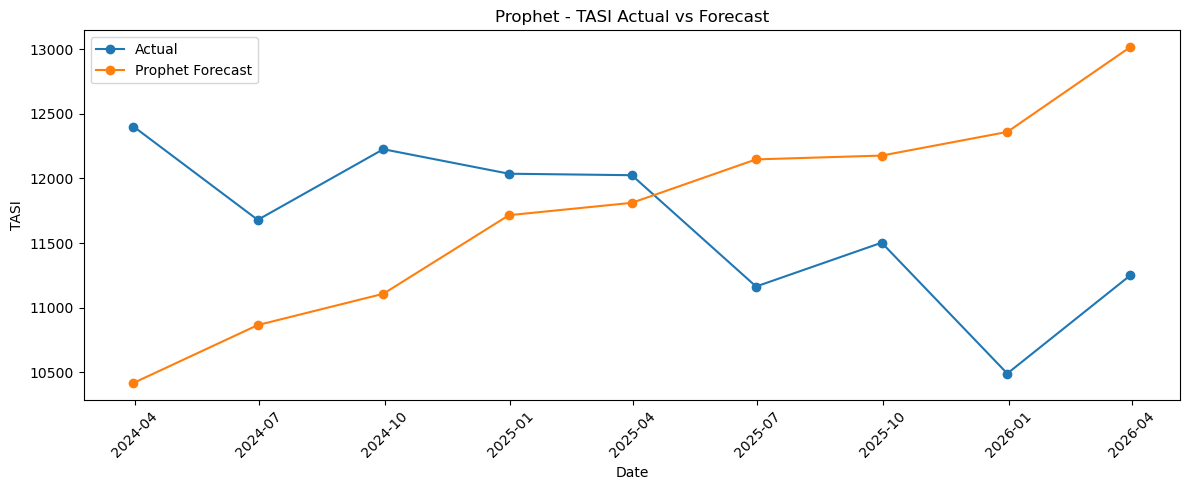

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    prophet_test['ds'],
    prophet_test['y'],
    marker='o',
    label='Actual'
)

plt.plot(
    prophet_prediction['ds'],
    prophet_prediction['yhat'],
    marker='o',
    label='Prophet Forecast'
)

plt.xlabel('Date')
plt.ylabel('TASI')
plt.title('Prophet - TASI Actual vs Forecast')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [63]:
# تجهيز بيانات Random Forest

rf_df = prophet_df.copy()

# إنشاء Lag Features
rf_df['Lag_1'] = rf_df['y'].shift(1)
rf_df['Lag_2'] = rf_df['y'].shift(2)
rf_df['Lag_3'] = rf_df['y'].shift(3)
rf_df['Lag_4'] = rf_df['y'].shift(4)

# حذف الصفوف التي لا تحتوي على Lags
rf_df = rf_df.dropna().reset_index(drop=True)

print("Random Forest data shape:", rf_df.shape)
display(rf_df.head())

Random Forest data shape: (40, 6)


,ds,y,Lag_1,Lag_2,Lag_3,Lag_4
0,2016-06-30,6499.88,6223.13,6911.76,7404.14,9086.89
1,2016-09-30,5623.34,6499.88,6223.13,6911.76,7404.14
2,2016-12-31,7210.43,5623.34,6499.88,6223.13,6911.76
3,2017-03-31,7001.63,7210.43,5623.34,6499.88,6223.13
4,2017-06-30,7425.72,7001.63,7210.43,5623.34,6499.88


In [64]:
# تقسيم بيانات Random Forest
rf_train = rf_df.iloc[:-9].copy()
rf_test = rf_df.iloc[-9:].copy()

# Features و Target
features = ['Lag_1', 'Lag_2', 'Lag_3', 'Lag_4']

X_train = rf_train[features]
y_train = rf_train['y']

X_test = rf_test[features]
y_test = rf_test['y']

print("Random Forest Train:", X_train.shape)
print("Random Forest Test :", X_test.shape)

print("\nTest dates:")
display(rf_test[['ds', 'y']])

Random Forest Train: (31, 4)
Random Forest Test : (9, 4)

Test dates:


,ds,y
31,2024-03-31,12401.56
32,2024-06-30,11679.50
33,2024-09-30,12226.10
34,2024-12-31,12036.50
35,2025-03-31,12025.05
36,2025-06-30,11163.96
37,2025-09-30,11502.97
38,2025-12-31,10490.69
39,2026-03-31,11249.54


In [65]:
from sklearn.ensemble import RandomForestRegressor

# إنشاء نموذج Random Forest
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

# تدريب النموذج
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [66]:
# التنبؤ على بيانات الاختبار
rf_prediction = rf_model.predict(X_test)

print("Random Forest forecast generated successfully!")

# عرض Actual مقابل Forecast
rf_comparison = pd.DataFrame({
    'Date': rf_test['ds'].values,
    'Actual': y_test.values,
    'Forecast': rf_prediction
})

display(rf_comparison)

Random Forest forecast generated successfully!


,Date,Actual,Forecast
0,2024-03-31,12401.56,11474.251298
1,2024-06-30,11679.50,11723.709735
2,2024-09-30,12226.10,11227.684161
3,2024-12-31,12036.50,11020.484499
4,2025-03-31,12025.05,11207.246961
5,2025-06-30,11163.96,11163.987883
6,2025-09-30,11502.97,11400.127133
7,2025-12-31,10490.69,11036.257084
8,2026-03-31,11249.54,11783.774304


In [67]:
# حساب مقاييس Random Forest

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_prediction))
rf_mae = mean_absolute_error(y_test, rf_prediction)
rf_mape = mean_absolute_percentage_error(y_test, rf_prediction)

print("Random Forest Results")
print("=" * 40)
print(f"RMSE : {rf_rmse:.4f}")
print(f"MAE  : {rf_mae:.4f}")
print(f"MAPE : {rf_mape:.4f}")
print(f"MAPE %: {rf_mape * 100:.2f}%")

Random Forest Results
RMSE : 679.3302
MAE  : 554.0472
MAPE : 0.0468
MAPE %: 4.68%


In [68]:
rf_result = pd.DataFrame({
    'Model': ['Random Forest'],
    'RMSE': [rf_rmse],
    'MAE': [rf_mae],
    'MAPE': [rf_mape]
})

display(rf_result)

,Model,RMSE,MAE,MAPE
0,Random Forest,679.330211,554.047217,0.046786


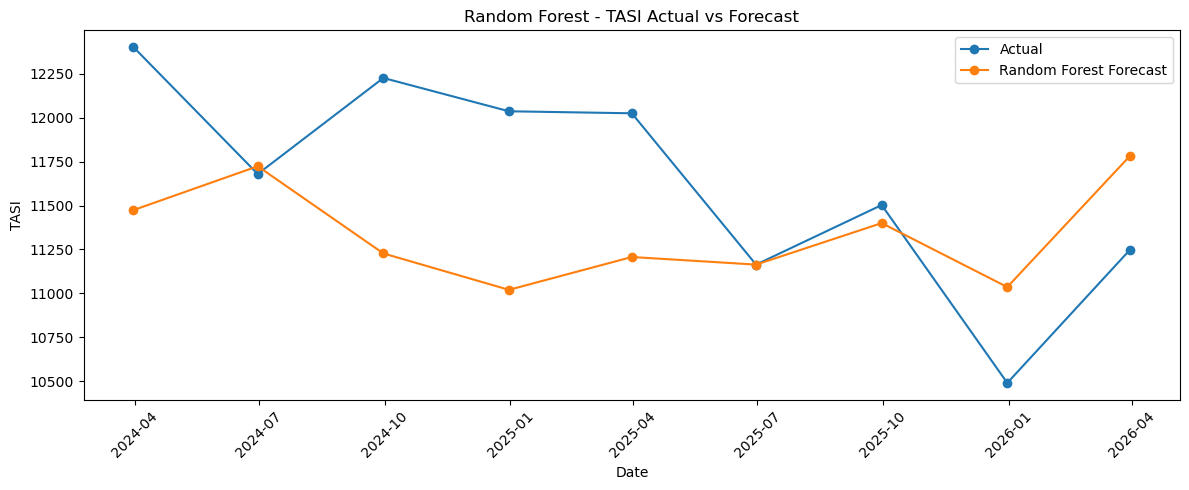

In [69]:
plt.figure(figsize=(12, 5))

plt.plot(
    rf_test['ds'],
    y_test,
    marker='o',
    label='Actual'
)

plt.plot(
    rf_test['ds'],
    rf_prediction,
    marker='o',
    label='Random Forest Forecast'
)

plt.xlabel('Date')
plt.ylabel('TASI')
plt.title('Random Forest - TASI Actual vs Forecast')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [70]:
# تجهيز بيانات XGBoost
xgb_df = prophet_df.copy()

# إنشاء Lag Features
xgb_df['Lag_1'] = xgb_df['y'].shift(1)
xgb_df['Lag_2'] = xgb_df['y'].shift(2)
xgb_df['Lag_3'] = xgb_df['y'].shift(3)
xgb_df['Lag_4'] = xgb_df['y'].shift(4)

# إضافة بعض الخصائص الزمنية
xgb_df['Year'] = xgb_df['ds'].dt.year
xgb_df['Quarter'] = xgb_df['ds'].dt.quarter

# حذف الصفوف التي لا تحتوي على Lags
xgb_df = xgb_df.dropna().reset_index(drop=True)

print("XGBoost data shape:", xgb_df.shape)
display(xgb_df.head())

XGBoost data shape: (40, 8)


,ds,y,Lag_1,Lag_2,Lag_3,Lag_4,Year,Quarter
0,2016-06-30,6499.88,6223.13,6911.76,7404.14,9086.89,2016,2
1,2016-09-30,5623.34,6499.88,6223.13,6911.76,7404.14,2016,3
2,2016-12-31,7210.43,5623.34,6499.88,6223.13,6911.76,2016,4
3,2017-03-31,7001.63,7210.43,5623.34,6499.88,6223.13,2017,1
4,2017-06-30,7425.72,7001.63,7210.43,5623.34,6499.88,2017,2


In [71]:
# تقسيم بيانات XGBoost
xgb_train = xgb_df.iloc[:-9].copy()
xgb_test = xgb_df.iloc[-9:].copy()

# تحديد الخصائص
xgb_features = [
    'Lag_1',
    'Lag_2',
    'Lag_3',
    'Lag_4',
    'Year',
    'Quarter'
]

X_xgb_train = xgb_train[xgb_features]
y_xgb_train = xgb_train['y']

X_xgb_test = xgb_test[xgb_features]
y_xgb_test = xgb_test['y']

print("XGBoost Train:", X_xgb_train.shape)
print("XGBoost Test :", X_xgb_test.shape)

print("\nTest dates:")
display(xgb_test[['ds', 'y']])

XGBoost Train: (31, 6)
XGBoost Test : (9, 6)

Test dates:


,ds,y
31,2024-03-31,12401.56
32,2024-06-30,11679.50
33,2024-09-30,12226.10
34,2024-12-31,12036.50
35,2025-03-31,12025.05
36,2025-06-30,11163.96
37,2025-09-30,11502.97
38,2025-12-31,10490.69
39,2026-03-31,11249.54


In [78]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

xgb_model.fit(X_xgb_train, y_xgb_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [79]:
# التنبؤ على بيانات الاختبار
xgb_prediction = xgb_model.predict(X_xgb_test)

print("XGBoost forecast generated successfully!")

# إنشاء جدول المقارنة
xgb_comparison = pd.DataFrame({
    'Date': xgb_test['ds'].values,
    'Actual': y_xgb_test.values,
    'Forecast': xgb_prediction
})

display(xgb_comparison)

XGBoost forecast generated successfully!


,Date,Actual,Forecast
0,2024-03-31,12401.56,11976.268555
1,2024-06-30,11679.50,11532.659180
2,2024-09-30,12226.10,10889.733398
3,2024-12-31,12036.50,10640.140625
4,2025-03-31,12025.05,11066.968750
5,2025-06-30,11163.96,10709.414062
6,2025-09-30,11502.97,10861.836914
7,2025-12-31,10490.69,10609.194336
8,2026-03-31,11249.54,11909.161133


In [80]:
# حساب مقاييس XGBoost

xgb_rmse = np.sqrt(mean_squared_error(y_xgb_test, xgb_prediction))
xgb_mae = mean_absolute_error(y_xgb_test, xgb_prediction)
xgb_mape = mean_absolute_percentage_error(y_xgb_test, xgb_prediction)

print("XGBoost Results")
print("=" * 40)
print(f"RMSE : {xgb_rmse:.4f}")
print(f"MAE  : {xgb_mae:.4f}")
print(f"MAPE : {xgb_mape:.4f}")
print(f"MAPE %: {xgb_mape * 100:.2f}%")

XGBoost Results
RMSE : 811.2307
MAE  : 681.8604
MAPE : 0.0576
MAPE %: 5.76%


In [81]:
xgb_result = pd.DataFrame({
    'Model': ['XGBoost'],
    'RMSE': [xgb_rmse],
    'MAE': [xgb_mae],
    'MAPE': [xgb_mape]
})

display(xgb_result)

,Model,RMSE,MAE,MAPE
0,XGBoost,811.230675,681.860443,0.057582


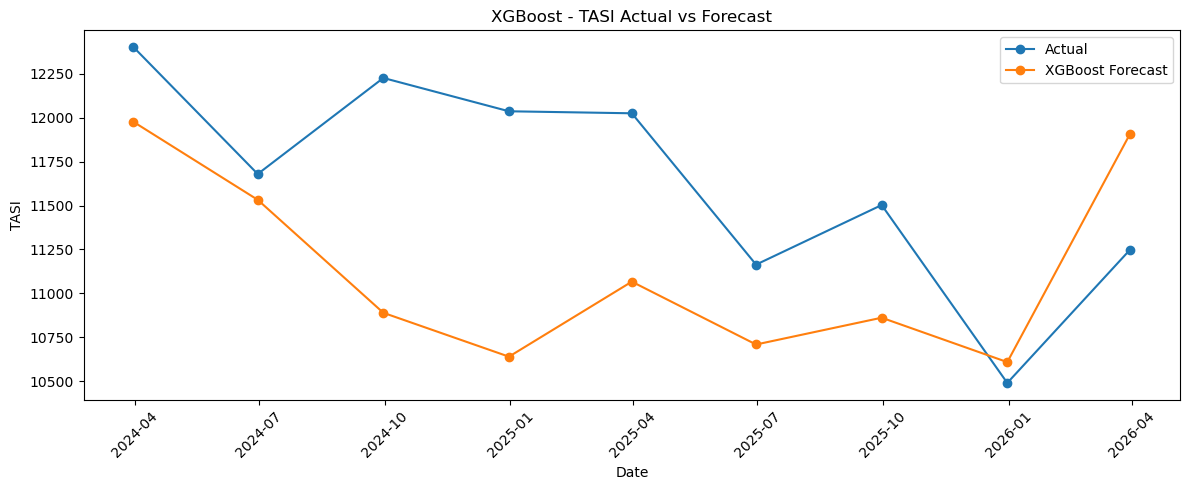

In [82]:
plt.figure(figsize=(12, 5))

plt.plot(
    xgb_test['ds'],
    y_xgb_test,
    marker='o',
    label='Actual'
)

plt.plot(
    xgb_test['ds'],
    xgb_prediction,
    marker='o',
    label='XGBoost Forecast'
)

plt.xlabel('Date')
plt.ylabel('TASI')
plt.title('XGBoost - TASI Actual vs Forecast')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
# =========================
# LSTM - Train/Test Split
# =========================

train_size = 35

train_lstm = lstm_df.iloc[:train_size].copy()
test_lstm = lstm_df.iloc[train_size:].copy()

print("Training observations:", len(train_lstm))
print("Testing observations:", len(test_lstm))

print("\nTraining period:")
print(train_lstm.iloc[0]['الفترة \nPeriod  '])
print("to")
print(train_lstm.iloc[-1]['الفترة \nPeriod  '])

print("\nTesting period:")
print(test_lstm.iloc[0]['الفترة \nPeriod  '])
print("to")
print(test_lstm.iloc[-1]['الفترة \nPeriod  '])

Training observations: 35
Testing observations: 9

Training period:
النصف الأول عام  2015م
First half 2015
to
الربع الرابع عام   2023م
Fourth quarter 2023

Testing period:
الربع الأول عام  2024م
First quarter 2024
to
الربع الأول عام 2026م
First quarter 2026


In [11]:
# =========================
# LSTM - Data Scaling
# =========================

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

# Fit only on training data
train_scaled = scaler.fit_transform(
    train_lstm[['TASI']]
)

# Transform test data using the same scaler
test_scaled = scaler.transform(
    test_lstm[['TASI']]
)

print("Scaled training shape:", train_scaled.shape)
print("Scaled testing shape:", test_scaled.shape)

print("\nFirst 5 scaled training values:")
print(train_scaled[:5])

print("\nFirst 5 scaled testing values:")
print(test_scaled[:5])

Scaled training shape: (35, 1)
Scaled testing shape: (9, 1)

First 5 scaled training values:
[[0.46384387]
 [0.23848744]
 [0.17254716]
 [0.08032479]
 [0.11738757]]

First 5 scaled testing values:
[[0.9077495 ]
 [0.81105013]
 [0.88425163]
 [0.85886011]
 [0.85732671]]


In [12]:
# =========================
# LSTM - Create Sequences
# =========================

look_back = 4

def create_sequences(data, look_back):
    X = []
    y = []

    for i in range(len(data) - look_back):
        X.append(data[i:i + look_back, 0])
        y.append(data[i + look_back, 0])

    return np.array(X), np.array(y)


# Create training sequences
X_train_lstm, y_train_lstm = create_sequences(
    train_scaled,
    look_back
)

print("X_train shape before reshape:", X_train_lstm.shape)
print("y_train shape:", y_train_lstm.shape)

# Reshape for LSTM:
# [samples, time steps, features]
X_train_lstm = X_train_lstm.reshape(
    X_train_lstm.shape[0],
    X_train_lstm.shape[1],
    1
)

print("X_train shape after reshape:", X_train_lstm.shape)

X_train shape before reshape: (31, 4)
y_train shape: (31,)
X_train shape after reshape: (31, 4, 1)


In [13]:
# =========================
# LSTM - Prepare Test Sequences
# =========================

# Combine the last look_back training values
# with all test values
test_input = np.concatenate(
    [train_scaled[-look_back:], test_scaled],
    axis=0
)

# Create test sequences
X_test_lstm, y_test_lstm = create_sequences(
    test_input,
    look_back
)

# Reshape for LSTM
X_test_lstm = X_test_lstm.reshape(
    X_test_lstm.shape[0],
    X_test_lstm.shape[1],
    1
)

print("X_test shape:", X_test_lstm.shape)
print("y_test shape:", y_test_lstm.shape)

X_test shape: (9, 4, 1)
y_test shape: (9,)


In [14]:
# =========================
# LSTM - Build Model
# =========================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model_lstm = Sequential()

model_lstm.add(
    LSTM(
        50,
        return_sequences=True,
        input_shape=(look_back, 1)
    )
)

model_lstm.add(Dropout(0.2))

model_lstm.add(
    LSTM(50)
)

model_lstm.add(Dropout(0.2))

model_lstm.add(Dense(1))

model_lstm.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model_lstm.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_1 (LSTM)                (None, 4, 50)             10400     
_________________________________________________________________
dropout (Dropout)            (None, 4, 50)             0         
_________________________________________________________________
lstm_2 (LSTM)                (None, 50)                20200     
_________________________________________________________________
dropout_1 (Dropout)          (None, 50)                0         
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 51        
Total params: 30,651
Trainable params: 30,651
Non-trainable params: 0
_________________________________________________________________


In [15]:
# =========================
# LSTM - Model Training
# =========================

history_lstm = model_lstm.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=100,
    batch_size=4,
    validation_split=0.1,
    shuffle=False,
    verbose=1
)

print("\nLSTM training completed successfully.")

Epoch 1/100
7/7 [==============================] - 1s 148ms/step - loss: 0.1685 - val_loss: 0.3460
Epoch 2/100
7/7 [==============================] - 0s 6ms/step - loss: 0.0946 - val_loss: 0.1749
Epoch 3/100
7/7 [==============================] - 0s 6ms/step - loss: 0.0475 - val_loss: 0.0466
Epoch 4/100
7/7 [==============================] - 0s 5ms/step - loss: 0.0300 - val_loss: 0.0109
Epoch 5/100
7/7 [==============================] - 0s 9ms/step - loss: 0.0428 - val_loss: 0.0117
Epoch 6/100
7/7 [==============================] - 0s 8ms/step - loss: 0.0377 - val_loss: 0.0221
Epoch 7/100
7/7 [==============================] - 0s 9ms/step - loss: 0.0305 - val_loss: 0.0251
Epoch 8/100
7/7 [==============================] - 0s 8ms/step - loss: 0.0329 - val_loss: 0.0221
Epoch 9/100
7/7 [==============================] - 0s 8ms/step - loss: 0.0251 - val_loss: 0.0179
Epoch 10/100
7/7 [==============================] - 0s 8ms/step - loss: 0.0318 - val_loss: 0.0149
Epoch 11/100
7/7 [=========

In [16]:
# =========================
# LSTM - Prediction
# =========================

# Generate predictions for the test set
y_pred_scaled = model_lstm.predict(
    X_test_lstm,
    verbose=0
)

print("Prediction shape:", y_pred_scaled.shape)

print("\nFirst 5 scaled predictions:")
print(y_pred_scaled[:5])

Prediction shape: (9, 1)

First 5 scaled predictions:
[[0.77228713]
 [0.825789  ]
 [0.82598156]
 [0.82893217]
 [0.82902557]]


In [17]:
# =========================
# LSTM - Inverse Scaling
# =========================

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

# Convert predictions back to original TASI scale
y_pred_lstm = scaler.inverse_transform(
    y_pred_scaled
)

# Convert actual test values back to original scale
y_actual_lstm = scaler.inverse_transform(
    y_test_lstm.reshape(-1, 1)
)

# Calculate metrics
rmse_lstm = np.sqrt(
    mean_squared_error(y_actual_lstm, y_pred_lstm)
)

mae_lstm = mean_absolute_error(
    y_actual_lstm,
    y_pred_lstm
)

mape_lstm = np.mean(
    np.abs(
        (y_actual_lstm - y_pred_lstm) /
        y_actual_lstm
    )
) * 100

print("LSTM Results")
print("=" * 40)
print(f"RMSE: {rmse_lstm:.4f}")
print(f"MAE : {mae_lstm:.4f}")
print(f"MAPE: {mape_lstm:.4f}%")

LSTM Results
RMSE: 533.3209
MAE : 424.5221
MAPE: 3.6792%


In [18]:
# =========================
# LSTM - Actual vs Forecast
# =========================

lstm_results = pd.DataFrame({
    'Period': test_lstm['الفترة \nPeriod  '].values,
    'Actual TASI': y_actual_lstm.flatten(),
    'LSTM Forecast': y_pred_lstm.flatten()
})

lstm_results['Error'] = (
    lstm_results['Actual TASI'] -
    lstm_results['LSTM Forecast']
)

lstm_results['Absolute Error'] = np.abs(
    lstm_results['Error']
)

display(lstm_results)

,Period,Actual TASI,LSTM Forecast,Error,Absolute Error
0,الربع الأول عام 2024م\nFirst quarter 2024,12401.56,11390.054688,1011.505312,1011.505312
1,الربع الثاني عام 2024م\nSecond quarter 2024,11679.50,11789.555664,-110.055664,110.055664
2,الربع الثالث عام 2024م\nThird quarter 2024,12226.10,11790.994141,435.105859,435.105859
3,الربع الرابع عام 2024م\nFourth quarter 2024,12036.50,11813.026367,223.473633,223.473633
4,الربع الأول عام 2025م\nFirst quarter 2025,12025.05,11813.723633,211.326367,211.326367
5,الربع الثاني عام 2025م\nSecond quarter 2025,11163.96,11833.447266,-669.487266,669.487266
6,الربع الثالث عام 2025م\nThird quarter 2025,11502.97,11475.738281,27.231719,27.231719
7,الربع الرابع عام 2025م\nFourth quarter 2025,10490.69,11331.228516,-840.538516,840.538516
8,الربع الأول عام 2026م\nFirst quarter 2026,11249.54,10957.565430,291.974570,291.974570


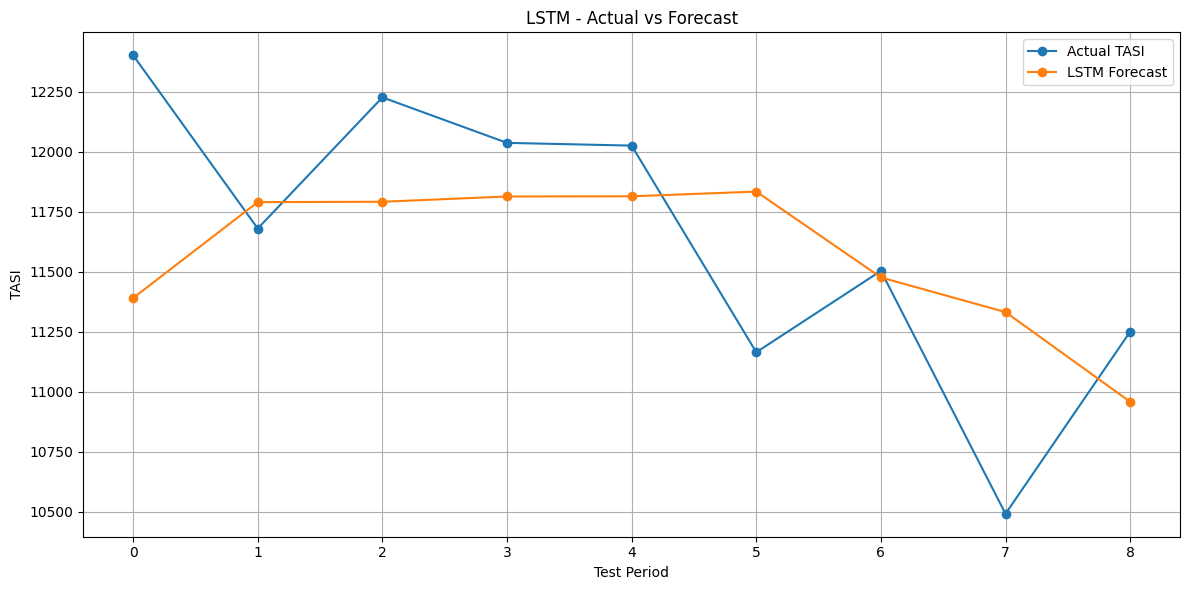

In [19]:
# =========================
# LSTM - Actual vs Forecast Plot
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    range(len(y_actual_lstm)),
    y_actual_lstm.flatten(),
    marker='o',
    label='Actual TASI'
)

plt.plot(
    range(len(y_pred_lstm)),
    y_pred_lstm.flatten(),
    marker='o',
    label='LSTM Forecast'
)

plt.title('LSTM - Actual vs Forecast')
plt.xlabel('Test Period')
plt.ylabel('TASI')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

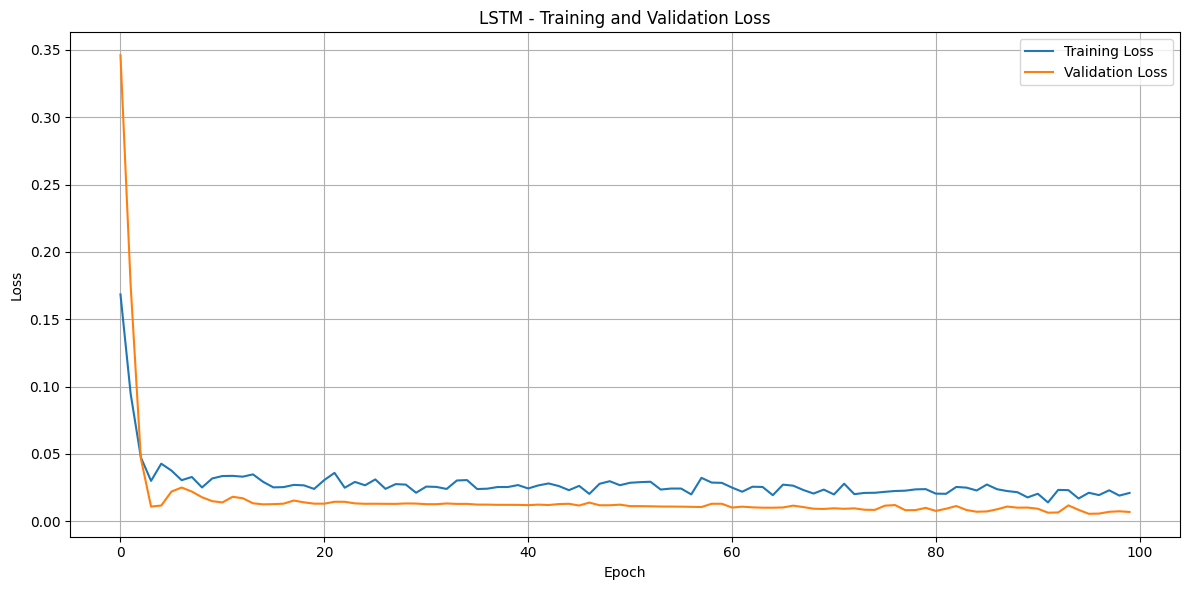

In [20]:
# =========================
# LSTM - Training Loss Plot
# =========================

plt.figure(figsize=(12, 6))

plt.plot(
    history_lstm.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_lstm.history['val_loss'],
    label='Validation Loss'
)

plt.title('LSTM - Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [3]:
# =========================
# ARIMA - Load TASI Data
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load the TASI dataset
file_name = "مؤشرات سوق الأسهم الرئيسية.csv"

tasi_arima_df = pd.read_csv(
    file_name,
    encoding='utf-8-sig'
)

print("Original dataset shape:", tasi_arima_df.shape)

# Rename the TASI column
tasi_arima_df = tasi_arima_df.rename(
    columns={
        tasi_arima_df.columns[1]: 'TASI'
    }
)

# Keep Period and TASI
tasi_arima_df = tasi_arima_df[
    [tasi_arima_df.columns[0], 'TASI']
].copy()

# Convert TASI to numeric
tasi_arima_df['TASI'] = pd.to_numeric(
    tasi_arima_df['TASI'],
    errors='coerce'
)

# Remove invalid/missing values
tasi_arima_df = tasi_arima_df.dropna().reset_index(drop=True)

# =========================
# Train / Test Split
# =========================

train_size = 35

arima_train_df = tasi_arima_df.iloc[:train_size].copy()
arima_test_df = tasi_arima_df.iloc[train_size:].copy()

arima_train = arima_train_df['TASI'].values
arima_test = arima_test_df['TASI'].values

print("\nClean dataset shape:", tasi_arima_df.shape)
print("Training observations:", len(arima_train))
print("Testing observations:", len(arima_test))

print("\nTraining period:")
print(arima_train_df.iloc[0, 0])
print("to")
print(arima_train_df.iloc[-1, 0])

print("\nTesting period:")
print(arima_test_df.iloc[0, 0])
print("to")
print(arima_test_df.iloc[-1, 0])

Original dataset shape: (48, 10)

Clean dataset shape: (44, 2)
Training observations: 35
Testing observations: 9

Training period:
النصف الأول عام  2015م
First half 2015
to
الربع الرابع عام   2023م
Fourth quarter 2023

Testing period:
الربع الأول عام  2024م
First quarter 2024
to
الربع الأول عام 2026م
First quarter 2026


In [4]:
# =========================
# ARIMA - Grid Search
# =========================

import warnings
warnings.filterwarnings("ignore")

best_aic = np.inf
best_order = None
best_model = None

# Search different ARIMA orders
for p in range(0, 4):
    for d in range(0, 3):
        for q in range(0, 4):

            try:
                model = ARIMA(
                    arima_train,
                    order=(p, d, q)
                )

                fitted_model = model.fit()

                if fitted_model.aic < best_aic:
                    best_aic = fitted_model.aic
                    best_order = (p, d, q)
                    best_model = fitted_model

            except Exception:
                continue

print("Best ARIMA order:", best_order)
print("Best AIC:", best_aic)

Best ARIMA order: (0, 2, 1)
Best AIC: 546.4978121342175


In [6]:
# =========================
# ARIMA - Model Building
# =========================

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# Best order found previously
arima_order = (0, 2, 1)

# Build and fit ARIMA model
arima_model = ARIMA(
    arima_train,
    order=arima_order
)

arima_fitted = arima_model.fit()

# Forecast the test period
arima_forecast = arima_fitted.forecast(
    steps=len(arima_test)
)

print("ARIMA model fitted successfully.")
print("ARIMA order:", arima_order)
print("Forecast observations:", len(arima_forecast))

ARIMA model fitted successfully.
ARIMA order: (0, 2, 1)
Forecast observations: 9


In [7]:
# =========================
# ARIMA - Actual vs Forecast
# =========================

arima_results = pd.DataFrame({
    'Period': arima_test_df.iloc[:, 0].values,
    'Actual TASI': arima_test,
    'ARIMA Forecast': arima_forecast
})

arima_results['Error'] = (
    arima_results['Actual TASI']
    - arima_results['ARIMA Forecast']
)

arima_results['Absolute Error'] = np.abs(
    arima_results['Error']
)

display(arima_results)

,Period,Actual TASI,ARIMA Forecast,Error,Absolute Error
0,الربع الأول عام 2024م\nFirst quarter 2024,12401.56,12152.022093,249.537907,249.537907
1,الربع الثاني عام 2024م\nSecond quarter 2024,11679.50,12336.654186,-657.154186,657.154186
2,الربع الثالث عام 2024م\nThird quarter 2024,12226.10,12521.286278,-295.186278,295.186278
3,الربع الرابع عام 2024م\nFourth quarter 2024,12036.50,12705.918371,-669.418371,669.418371
4,الربع الأول عام 2025م\nFirst quarter 2025,12025.05,12890.550464,-865.500464,865.500464
5,الربع الثاني عام 2025م\nSecond quarter 2025,11163.96,13075.182557,-1911.222557,1911.222557
6,الربع الثالث عام 2025م\nThird quarter 2025,11502.97,13259.814649,-1756.844649,1756.844649
7,الربع الرابع عام 2025م\nFourth quarter 2025,10490.69,13444.446742,-2953.756742,2953.756742
8,الربع الأول عام 2026م\nFirst quarter 2026,11249.54,13629.078835,-2379.538835,2379.538835


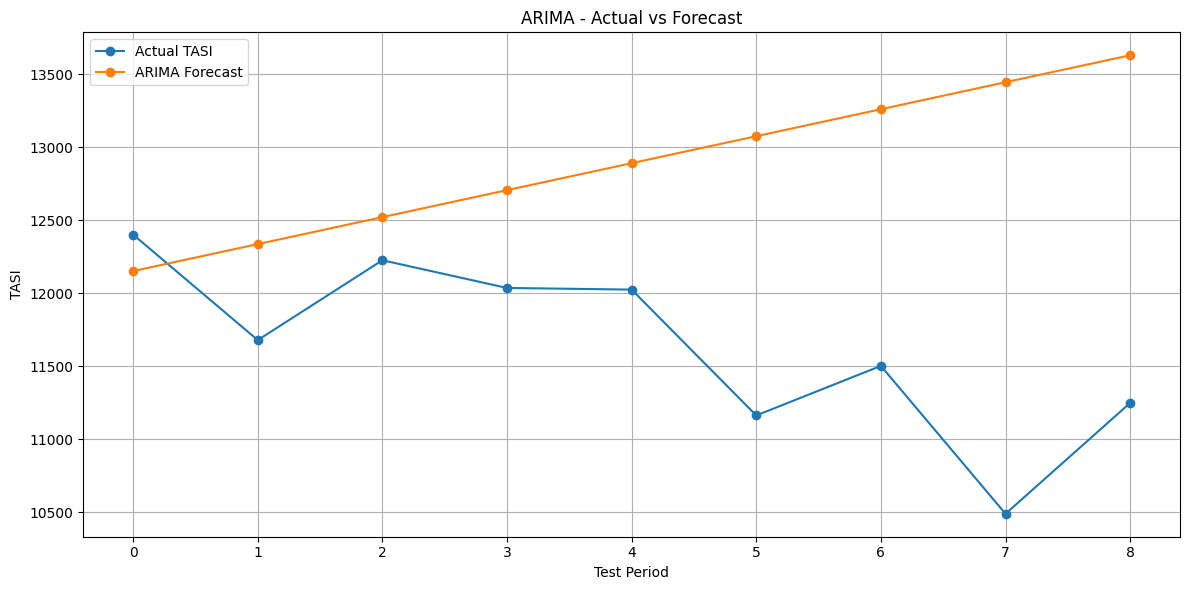

In [8]:
# =========================
# ARIMA - Actual vs Forecast Plot
# =========================

plt.figure(figsize=(12, 6))

plt.plot(
    range(len(arima_test)),
    arima_test,
    marker='o',
    label='Actual TASI'
)

plt.plot(
    range(len(arima_forecast)),
    arima_forecast,
    marker='o',
    label='ARIMA Forecast'
)

plt.title('ARIMA - Actual vs Forecast')
plt.xlabel('Test Period')
plt.ylabel('TASI')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [9]:
# =========================
# SARIMA - Grid Search
# =========================

from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

warnings.filterwarnings("ignore")

best_sarima_aic = np.inf
best_sarima_order = None
best_seasonal_order = None
best_sarima_model = None

# Non-seasonal parameters
p_values = range(0, 3)
d_values = range(0, 2)
q_values = range(0, 3)

# Seasonal parameters
P_values = range(0, 2)
D_values = range(0, 2)
Q_values = range(0, 2)

seasonal_period = 4

for p in p_values:
    for d in d_values:
        for q in q_values:
            for P in P_values:
                for D in D_values:
                    for Q in Q_values:

                        try:
                            model = SARIMAX(
                                arima_train,
                                order=(p, d, q),
                                seasonal_order=(
                                    P, D, Q, seasonal_period
                                ),
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            )

                            fitted_model = model.fit(
                                disp=False
                            )

                            if fitted_model.aic < best_sarima_aic:
                                best_sarima_aic = fitted_model.aic
                                best_sarima_order = (p, d, q)
                                best_seasonal_order = (
                                    P, D, Q, seasonal_period
                                )
                                best_sarima_model = fitted_model

                        except Exception:
                            continue

print("Best SARIMA order:", best_sarima_order)
print("Best seasonal order:", best_seasonal_order)
print("Best AIC:", best_sarima_aic)

Best SARIMA order: (0, 1, 2)
Best seasonal order: (0, 1, 1, 4)
Best AIC: 389.7210929348132


In [10]:
# =========================
# SARIMA - Forecast
# =========================

# Use the best SARIMA model found by Grid Search
sarima_forecast = best_sarima_model.forecast(
    steps=len(arima_test)
)

# Calculate RMSE
sarima_rmse = np.sqrt(
    mean_squared_error(
        arima_test,
        sarima_forecast
    )
)

# Calculate MAE
sarima_mae = mean_absolute_error(
    arima_test,
    sarima_forecast
)

# Calculate MAPE
sarima_mape = np.mean(
    np.abs(
        (arima_test - sarima_forecast)
        / arima_test
    )
) * 100

print("SARIMA Results")
print("=" * 40)
print("Order:", best_sarima_order)
print("Seasonal Order:", best_seasonal_order)
print(f"RMSE: {sarima_rmse:.4f}")
print(f"MAE : {sarima_mae:.4f}")
print(f"MAPE: {sarima_mape:.4f}%")

SARIMA Results
Order: (0, 1, 2)
Seasonal Order: (0, 1, 1, 4)
RMSE: 1883.7676
MAE : 1579.0130
MAPE: 14.0272%


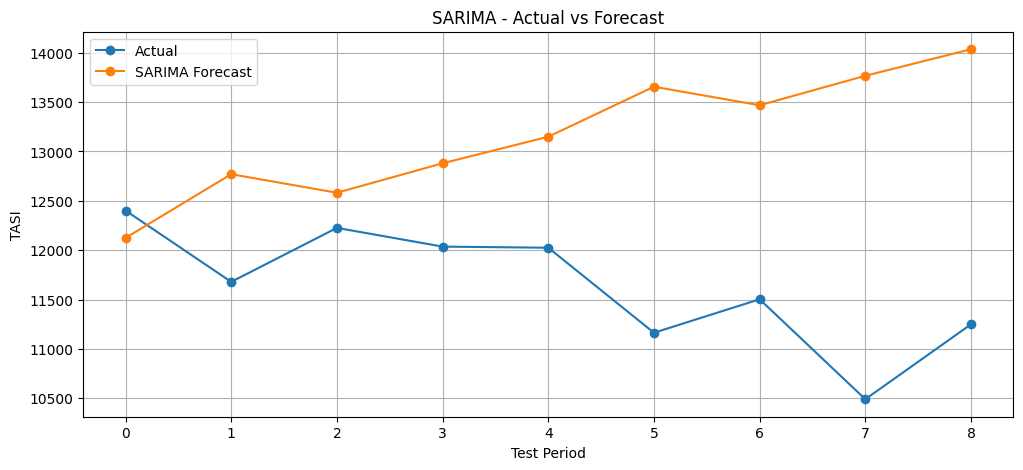

In [9]:
# =========================
# SARIMA - Actual vs Forecast
# =========================

plt.figure(figsize=(12, 5))

plt.plot(
    arima_test,
    label="Actual",
    marker="o"
)

plt.plot(
    sarima_forecast,
    label="SARIMA Forecast",
    marker="o"
)

plt.title("SARIMA - Actual vs Forecast")
plt.xlabel("Test Period")
plt.ylabel("TASI")
plt.legend()
plt.grid(True)
plt.show()

| Model         |       RMSE |        MAE |      MAPE |
| ------------- | ---------: | ---------: | --------: |
| **LSTM**      | **587.50** | **419.43** | **3.70%** |
| Random Forest |     679.33 |     554.05 |     4.68% |
| XGBoost       |     811.23 |     681.86 |     5.76% |
| Prophet       |    1248.63 |    1082.61 |     9.42% |
| ARIMA         |    1595.29 |    1304.24 |    11.61% |
| SARIMA        |    1883.77 |    1579.01 |    14.03% |
